In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

In [ ]:

train    = pd.read_csv('data/train.csv')           # columns: store_id, date, revenue
train.columns = train.columns.str.strip().str.lower()
if 'store_name' in train.columns:
    train = train[train['store_name'] != 'all stores']
else:
    train = train[train['store_id'] != 0]
calendar = pd.read_csv('data/calendar_events.csv') # columns: date, event_name (etc.)
sub_tmpl = pd.read_csv('data/forecast_submission.csv')  # id column

# Normalise column names to lowercase / strip whitespace
train.columns    = train.columns.str.strip().str.lower()
calendar.columns = calendar.columns.str.strip().str.lower()
sub_tmpl.columns = sub_tmpl.columns.str.strip().str.lower()

# Parse dates
train['date']    = pd.to_datetime(train['date'])
calendar['date'] = pd.to_datetime(calendar['date'])

EVENT_COL = 'event'

print("Train shape    :", train.shape)
print("Calendar shape :", calendar.shape)
print("Submission rows:", len(sub_tmpl))
print("Train columns  :", train.columns.tolist())
print("Calendar sample:\n", calendar.head(3))

Train shape    : (18766, 4)
Calendar shape : (162, 2)
Submission rows: 1012
Train columns  : ['store_id', 'store_name', 'date', 'revenue']
Calendar sample:
         date          event
0 2011-02-06      SuperBowl
1 2011-02-14  ValentinesDay
2 2011-02-21  PresidentsDay


In [ ]:
def add_time_and_event_features(df, calendar):
    df = pd.merge(df, calendar[['date', EVENT_COL]], on='date', how='left')
 
    df['day_of_week']    = df['date'].dt.dayofweek
    df['day_of_month']   = df['date'].dt.day
    df['month']          = df['date'].dt.month
    df['year']           = df['date'].dt.year
    df['week_of_year']   = df['date'].dt.isocalendar().week.astype(int)
    df['quarter']        = df['date'].dt.quarter
    df['is_weekend']     = df['day_of_week'].isin([5, 6]).astype(int)
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
    df['is_month_end']   = df['date'].dt.is_month_end.astype(int)
 
    df = df.sort_values(['store_id', 'date']).reset_index(drop=True)

    df['event_name'] = df[EVENT_COL].astype('category')
    df['event_yesterday'] = df.groupby('store_id')['has_event'].shift(1).fillna(0).astype(int)
    df['event_tomorrow']  = df.groupby('store_id')['has_event'].shift(-1).fillna(0).astype(int)
    df['event_in_3days']  = (
        df.groupby('store_id')['has_event'].shift(-1).fillna(0) +
        df.groupby('store_id')['has_event'].shift(-2).fillna(0) +
        df.groupby('store_id')['has_event'].shift(-3).fillna(0)
    ).clip(0, 1).astype(int)
 
    return df
 
 
def add_lag_rolling_features(df):
    df = df.sort_values(['store_id', 'date']).reset_index(drop=True)
    grp = df.groupby('store_id')['revenue']
 
    for lag in [7, 14, 21, 28, 35, 42]:
        df[f'lag_{lag}'] = grp.shift(lag)
 
    # Rolling stats anchored at lag-7 (no data leakage)
    shifted7 = grp.shift(7)
    for window in [7, 14, 28]:
        df[f'rolling_mean_{window}'] = shifted7.groupby(df['store_id']).transform(
            lambda x: x.rolling(window, min_periods=1).mean())
        df[f'rolling_std_{window}']  = shifted7.groupby(df['store_id']).transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0))
        df[f'rolling_max_{window}']  = shifted7.groupby(df['store_id']).transform(
            lambda x: x.rolling(window, min_periods=1).max())
 
    # Same-day-of-week 4-week mean
    df['lag7_mean_4w'] = (df['lag_7'] + df['lag_14'] + df['lag_21'] + df['lag_28']) / 4
 
    return df
 
 
print("\nBuilding feature dataframe...")
df = add_time_and_event_features(train.copy(), calendar)
df = add_lag_rolling_features(df)
df = df.dropna(subset=['lag_42']).reset_index(drop=True)
df['store_id'] = df['store_id'].astype('category')
print(f"Feature df shape: {df.shape}")


Building feature dataframe...
Feature df shape: (18304, 34)


In [ ]:
LAG_FEATURES     = [f'lag_{d}' for d in [7, 14, 21, 28, 35, 42]]
ROLLING_FEATURES = [
    'rolling_mean_7',  'rolling_mean_14', 'rolling_mean_28',
    'rolling_std_7',   'rolling_std_14',  'rolling_std_28',
    'rolling_max_7',   'rolling_max_14',  'rolling_max_28',
    'lag7_mean_4w',
]
TIME_FEATURES  = [
    'day_of_week', 'day_of_month', 'month', 'year',
    'week_of_year', 'quarter', 'is_weekend',
    'is_month_start', 'is_month_end',
]
EVENT_FEATURES = ['has_event', 'event_yesterday', 'event_tomorrow', 'event_in_3days']
 
FEATURES = ['store_id', 'event_name'] + TIME_FEATURES + LAG_FEATURES + ROLLING_FEATURES + EVENT_FEATURES
TARGET   = 'revenue'

In [5]:
VALID_DAYS = 92
split_date = df['date'].max() - pd.Timedelta(days=VALID_DAYS)
 
train_df = df[df['date'] <= split_date]
valid_df  = df[df['date'] >  split_date]
 
X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_valid, y_valid = valid_df[FEATURES],  valid_df[TARGET]
 
print(f"\nTrain rows: {len(X_train):,}  |  Valid rows: {len(X_valid):,}")


Train rows: 17,292  |  Valid rows: 1,012


In [ ]:
model = lgb.LGBMRegressor(
    objective='regression_l2',
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=127,
    min_child_samples=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
 
print("Training model...")
model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(200),
    ],
    categorical_feature=['store_id', 'event_name'],
)
 
valid_preds = model.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, valid_preds))
print(f"\n Validation RMSE: {rmse:.2f}")
 
fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\nTop 15 features:")
print(fi.head(15).to_string())

Training model...
Training until validation scores don't improve for 100 rounds
[200]	valid_0's l2: 4.21181e+07
Early stopping, best iteration is:
[230]	valid_0's l2: 4.0981e+07

 Validation RMSE: 6401.64

Top 15 features:
day_of_month      3609
week_of_year      2609
lag_28            1631
lag7_mean_4w      1463
lag_7             1457
month             1322
day_of_week       1296
lag_35            1284
rolling_std_7     1189
lag_21            1184
lag_14            1090
lag_42            1078
rolling_std_28    1074
rolling_mean_7    1000
rolling_std_14     987


In [ ]:
print("\nPreparing iterative forecast...")
 
# Parse submission ids  →  store_id (int) + date
sub = sub_tmpl.copy()
sub['store_id'] = sub['id'].apply(lambda x: int(x.split('_')[0]))
sub['date']     = pd.to_datetime(sub['id'].apply(lambda x: x.split('_')[1]), format='%Y%m%d')
sub = sub.sort_values(['store_id', 'date']).reset_index(drop=True)
 
store_ids      = sorted(sub['store_id'].unique())
forecast_start = sub['date'].min()
forecast_end   = sub['date'].max()
 
# Seed history with all known training data
history = {}
for store_id, grp in train.groupby('store_id'):
    history[int(store_id)] = dict(zip(pd.to_datetime(grp['date']), grp['revenue'].values))
 
# Calendar event lookup  {date → event_str or None}
cal_lookup = dict(zip(calendar['date'], calendar[EVENT_COL]))
 
def has_event_on(d):
    return int(cal_lookup.get(d) is not None and not pd.isna(cal_lookup.get(d, np.nan)))
 
def get_lag(sid, date, lag_days):
    return history[sid].get(date - pd.Timedelta(days=lag_days), np.nan)
 
def get_rolling(sid, date, shift_days, window, stat):
    base   = date - pd.Timedelta(days=shift_days)
    values = [history[sid][base - pd.Timedelta(days=i)]
              for i in range(window)
              if (base - pd.Timedelta(days=i)) in history[sid]]
    if not values:
        return np.nan
    if stat == 'mean': return float(np.mean(values))
    if stat == 'std':  return float(np.std(values)) if len(values) > 1 else 0.0
    if stat == 'max':  return float(np.max(values))
 
results = []
all_dates = pd.date_range(forecast_start, forecast_end, freq='D')
 
for date in all_dates:
    rows = []
    for sid in store_ids:
        lags = {f'lag_{d}': get_lag(sid, date, d) for d in [7, 14, 21, 28, 35, 42]}
 
        rolling = {}
        for w in [7, 14, 28]:
            rolling[f'rolling_mean_{w}'] = get_rolling(sid, date, 7, w, 'mean')
            rolling[f'rolling_std_{w}']  = get_rolling(sid, date, 7, w, 'std')
            rolling[f'rolling_max_{w}']  = get_rolling(sid, date, 7, w, 'max')
 
        lag_vals = [lags[f'lag_{d}'] for d in [7, 14, 21, 28]]
        valid_lag_vals = [v for v in lag_vals if not np.isnan(v)]
        lag7_mean_4w   = float(np.mean(valid_lag_vals)) if valid_lag_vals else np.nan

        event_today = cal_lookup.get(date)
 
        row = dict(
            store_id       = sid,
            day_of_week    = date.dayofweek,
            day_of_month   = date.day,
            month          = date.month,
            year           = date.year,
            week_of_year   = date.isocalendar()[1],
            quarter        = (date.month - 1) // 3 + 1,
            is_weekend     = int(date.dayofweek in [5, 6]),
            is_month_start = int(date.day == 1),
            is_month_end   = int((date + pd.Timedelta(days=1)).month != date.month),
            event_name     = event_today if pd.notna(event_today) else np.nan,
            has_event      = int(pd.notna(event_today)),
            event_yesterday= has_event_on(date - pd.Timedelta(days=1)),
            event_tomorrow  = has_event_on(date + pd.Timedelta(days=1)),
            event_in_3days  = int(any(has_event_on(date + pd.Timedelta(days=k)) for k in [1,2,3])),
            lag7_mean_4w   = lag7_mean_4w,
            **lags,
            **rolling,
        )
        rows.append(row)
 
    X_day = pd.DataFrame(rows)[FEATURES].copy()
    X_day['store_id'] = X_day['store_id'].astype('category')
    X_day['event_name'] = X_day['event_name'].astype('category')
 
    # Fallback: fill any remaining NaNs with store rolling mean (edge of forecast window)
    mean_cols = [c for c in ROLLING_FEATURES if 'mean' in c]
    fallback   = X_day[mean_cols].mean(axis=1)
    X_day = X_day.apply(lambda col: col.fillna(fallback) if col.isna().any() else col)
 
    preds = model.predict(X_day).clip(0)   # revenue ≥ 0
 
    for sid, pred in zip(store_ids, preds):
        history[sid][date] = float(pred)
        date_str = date.strftime('%Y%m%d')
        results.append({'id': f'{sid}_{date_str}', 'prediction': float(pred)})
 
    if date.day == 1:
        print(f"  Forecasted through {date.strftime('%Y-%m-%d')}")
 
print("Iterative forecast complete.")


Preparing iterative forecast...
  Forecasted through 2015-10-01
  Forecasted through 2015-11-01
  Forecasted through 2015-12-01
Iterative forecast complete.


In [8]:
results_df = pd.DataFrame(results)
 
final = sub_tmpl[['id']].merge(results_df, on='id', how='left')
 
# Sanity-check: no missing predictions
missing = final['prediction'].isna().sum()
if missing:
    print(f" {missing} missing predictions — filling with global mean")
    final['prediction'] = final['prediction'].fillna(final['prediction'].mean())
 
final.to_csv('submission_1.csv', index=False)
print(f"\n Saved 'submission_1.csv'  ({len(final)} rows)")
print(final.head(10).to_string(index=False))
print(f"\nPrediction stats:\n{final['prediction'].describe()}")


 Saved 'submission_1.csv'  (1012 rows)
        id    prediction
0_20151001 283425.235199
0_20151002 311549.858673
0_20151003 365305.776864
0_20151004 366590.775159
0_20151005 308388.700238
0_20151006 283808.625346
0_20151007 279042.189261
0_20151008 273557.365866
0_20151009 316460.252364
0_20151010 355930.956941

Prediction stats:
count      1012.000000
mean      51909.623745
std       75428.067935
min        5952.133732
25%       22475.780210
50%       27713.038203
75%       35657.099942
max      366590.775159
Name: prediction, dtype: float64


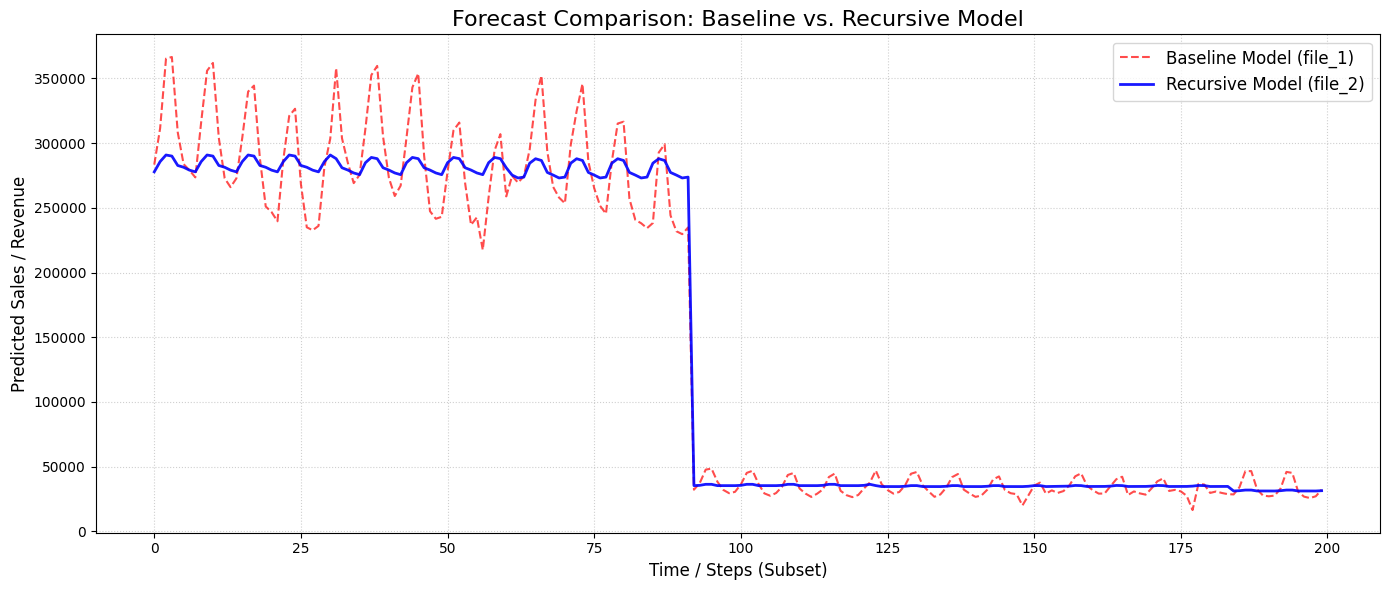

In [11]:
# 1. Load the submission files
# Assuming file_1.csv is the baseline and file_2.csv is the recursive model
baseline_df = pd.read_csv('submission_1.csv')
recursive_df = pd.read_csv('my_first_submission.csv')

# 2. Identify the prediction column 
# Note: Change 'prediction' to the actual name of your target column (e.g., 'sales', 'revenue', or 'F1')
target_col = 'prediction' # <--- UPDATE THIS IF NEEDED

# 3. Optional: Select a subset of data to make the plot readable
# Plotting 10,000+ points looks like a messy blob. Let's plot the first 200 predictions.
subset_limit = 200
baseline_subset = baseline_df[target_col].iloc[:subset_limit]
recursive_subset = recursive_df[target_col].iloc[:subset_limit]

# 4. Create the plot
plt.figure(figsize=(14, 6))

plt.plot(baseline_subset.values, label='Baseline Model (file_1)', 
         color='red', linestyle='--', alpha=0.7)

plt.plot(recursive_subset.values, label='Recursive Model (file_2)', 
         color='blue', linewidth=2, alpha=0.9)

# Add titles and labels
plt.title('Forecast Comparison: Baseline vs. Recursive Model', fontsize=16)
plt.xlabel('Time / Steps (Subset)', fontsize=12)
plt.ylabel('Predicted Sales / Revenue', fontsize=12)

# Add a grid and legend
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()